In [23]:
# Cell 1: Title + Imports
# 03_upgraded_prototype.ipynb
# Upgraded IDA Core Engine with Preprocessing, LAB Colors, After Feature

import cv2
import numpy as np
from sklearn.cluster import KMeans
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import json
import os
from datetime import datetime

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [24]:
# Cell 2: Load Models
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)
print("✅ MobileNetV2 loaded")

✅ MobileNetV2 loaded


In [25]:
# Cell 3: Helper Functions (Core Engine - Upgraded)
def preprocess_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, target_size)
    img_denoised = cv2.fastNlMeansDenoisingColored(cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR), None, 10, 10, 7, 21)
    img_denoised = cv2.cvtColor(img_denoised, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img_denoised, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced_lab = cv2.merge((cl, a, b))
    enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    return enhanced_rgb, img_rgb

def extract_color_palette(image_rgb, n_colors=5):
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    pixels = lab.reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(pixels)
    colors_lab = kmeans.cluster_centers_.astype(np.float32)
    colors_lab_reshaped = colors_lab.reshape(1, n_colors, 3)
    colors_rgb = cv2.cvtColor(colors_lab_reshaped, cv2.COLOR_LAB2RGB)
    colors_rgb = colors_rgb.reshape(-1, 3)
    labels = kmeans.labels_
    counts = np.bincount(labels)
    percentages = (counts / len(labels)) * 100
    colors_rgb_int = np.clip(colors_rgb, 0, 255).astype(np.uint8)
    hex_colors = ['#{:02x}{:02x}{:02x}'.format(r, g, b) for r, g, b in colors_rgb_int]
    return colors_rgb, hex_colors, percentages

def visualize_palette(colors_rgb, hex_colors, percentages):
    plt.figure(figsize=(12, 4))
    plt.imshow([colors_rgb / 255])
    plt.axis('off')
    for i, (hex_c, perc) in enumerate(zip(hex_colors, percentages)):
        plt.text(i, 0.5, f"{hex_c}\n{perc:.1f}%", ha='center', va='center',
                 color='white' if np.mean(colors_rgb[i]) < 120 else 'black', fontsize=12, fontweight='bold')
    plt.title("Dominant Color Palette", fontsize=16)
    plt.tight_layout()
    plt.show()

def detect_style(image_rgb, features):
    brightness = np.mean(image_rgb)
    color_variance = np.var(image_rgb)
    edge_density = np.sum(cv2.Canny(cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY), 100, 200) > 0) / (image_rgb.shape[0] * image_rgb.shape[1])
    feat_mean = np.mean(features)
    if brightness > 180 and edge_density < 0.08 and color_variance < 1500:
        return "Minimalist"
    elif edge_density > 0.25 or feat_mean > 2.5:
        return "Industrial"
    elif len(np.unique(np.round(image_rgb / 30), axis=0)) > 8:
        return "Bohemian"
    elif brightness < 110:
        return "Rustic"
    else:
        return "Modern"

def get_recommendations(style, colors_rgb, hex_colors):
    recs = {
        'Minimalist': "Clean lines, white/gray walls, simple furniture, lots of negative space.",
        'Modern': "Sleek sofas, geometric patterns, metal accents, bold lighting.",
        'Industrial': "Exposed brick, metal shelves, leather, raw wood, dark tones.",
        'Bohemian': "Layered textiles, plants, vintage rugs, colorful pillows, macramé.",
        'Rustic': "Warm wood, stone, cozy blankets, earthy tones, natural textures."
    }
    color_tip = f"Recommended wall color: {hex_colors[0]} | Accent: {hex_colors[1]}"
    return f"{recs[style]} {color_tip}"

✅ Image loaded successfully


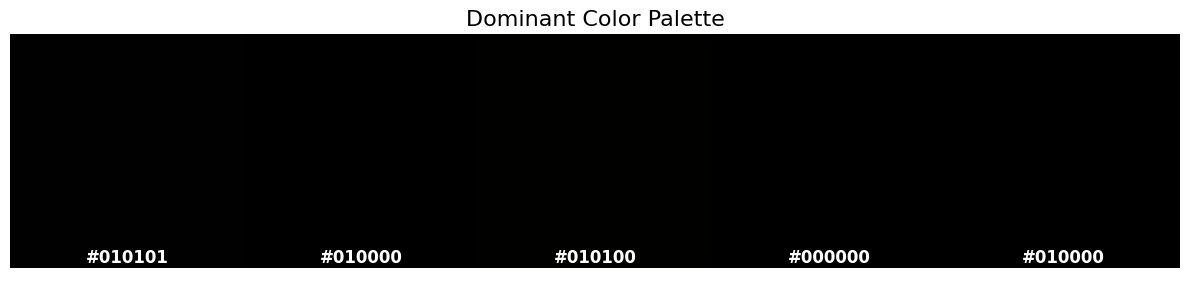

🎨 Detected Style: Bohemian
💡 Recommendations: Layered textiles, plants, vintage rugs, colorful pillows, macramé. Recommended wall color: #010101 | Accent: #010000
✅ Analysis saved to results/ folder!


In [26]:
# Cell: Run Analysis (Change Path)
image_path = "C:\\Users\\Sheikh Zain\\capstone-2025\\data\\samples\\pexels-pixabay-271654.jpg"   # ← your image

if not os.path.exists(image_path):
    print("❌ Image not found! Please add sample images to data/samples/")
else:
    print("✅ Image loaded successfully")
    
    enhanced_rgb, original_rgb = preprocess_image(image_path)
    
    # FIXED palette extraction
    colors_rgb, hex_colors, percentages = extract_color_palette(enhanced_rgb)
    
    visualize_palette(colors_rgb, hex_colors, percentages)
    
    # Continue with style detection...
    img_array = np.expand_dims(cv2.resize(enhanced_rgb, (224, 224)), axis=0)
    img_pre = preprocess_input(img_array)
    features = feature_extractor.predict(img_pre, verbose=0)[0]
    flat_features = features.flatten()
    
    style = detect_style(enhanced_rgb, flat_features)
    suggestions = get_recommendations(style, colors_rgb, hex_colors)
    
    print(f"🎨 Detected Style: {style}")
    print(f"💡 Recommendations: {suggestions}")
    
    # Save results
    os.makedirs("results", exist_ok=True)
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    result = {
        "style": style, 
        "colors_hex": hex_colors, 
        "color_percentages": [round(p, 2) for p in percentages],
        "recommendations": suggestions
    }
    with open(f"results/{base_name}_analysis.json", "w") as f:
        json.dump(result, f, indent=2)
    
    print("✅ Analysis saved to results/ folder!")

c:\Users\Sheikh Zain\capstone-2025\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


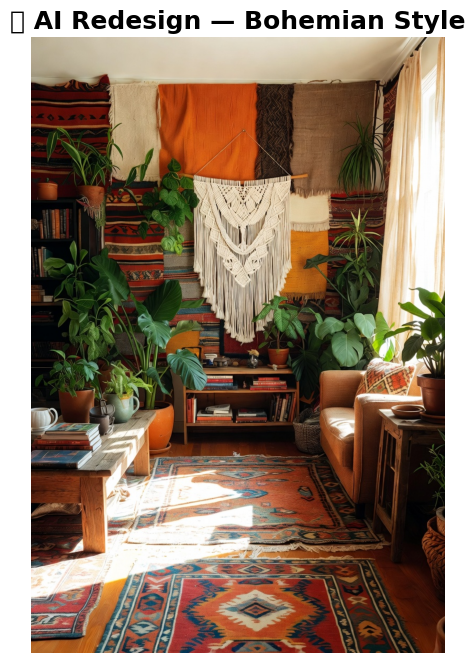

In [21]:
# Cell 5: Show AI-Generated "After" Redesign
suggested_images = {
    'Modern': 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\modern_after.jpg',
    'Minimalist': 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\minimalist_after.jpg',
    'Industrial': 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\industrial_after.jpg',
    'Bohemian': 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\bohemian_after.jpg',
    'Rustic': 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\rustic_after.jpg'
}

after_image_path = suggested_images.get(style, 'C:\\Users\\Sheikh Zain\\capstone-2025\\data\\suggested\\modern_after.jpg')
if os.path.exists(after_image_path):
    after_img = mpimg.imread(after_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(after_img)
    plt.title(f"✨ AI Redesign — {style} Style", fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ After image not found!")